# Paper 001: inspect AAD and models on a Colab A100

Open this local notebook in VS Code, connect it through the official Google
Colab extension, and run the cells from top to bottom. The Python kernel and
filesystem are on the remote Colab machine. This workflow inspects training
data and model plumbing; it does not train, rank models, or open test clips.

## 1. Confirm the remote A100 runtime

In [ ]:
import subprocess
import sys

gpu_report = subprocess.run(
    [
        "nvidia-smi",
        "--query-gpu=name,memory.total,driver_version",
        "--format=csv,noheader",
    ],
    check=True,
    capture_output=True,
    text=True,
)
gpu_summary = gpu_report.stdout.strip()
if "A100" not in gpu_summary:
    raise RuntimeError(f"Expected an A100 runtime, found: {gpu_summary}")
print("Python:", sys.executable)
print("GPU:", gpu_summary)

Python: /usr/bin/python3
GPU: NVIDIA A100-SXM4-80GB, 81920 MiB, 580.82.07


## 2. Reuse the remote code and dataset

The local notebook is only the interface. Source code must also exist on the
remote Colab filesystem. This cell reuses a checkout under
`/content/phd_research`, pulls only when it is clean, and clones only when it
is absent. It installs the exact direct dependencies declared in
`requirements.txt` on every run, validates the PyTorch/CUDA stack, and
reuses the existing AAD KaggleHub cache. It downloads the public dataset
only when the current runtime has no cached copy.

In [ ]:
import importlib
from importlib import metadata
import os
from pathlib import Path

REPOSITORY_URL = "https://github.com/sanelehlabisa/phd_research.git"
REPOSITORY_ROOT = Path("/content/phd_research")
IMPLEMENTATION_DIR = (
    REPOSITORY_ROOT
    / "papers"
    / "001-journal-abnormal-activity-recognition"
    / "implementation"
)

if (REPOSITORY_ROOT / ".git").is_dir():
    git_status = subprocess.run(
        ["git", "status", "--porcelain"],
        cwd=REPOSITORY_ROOT,
        check=True,
        capture_output=True,
        text=True,
    )
    if git_status.stdout.strip():
        print("Reusing checkout; git pull skipped because it has local changes.")
    else:
        subprocess.run(
            ["git", "pull", "--ff-only"],
            cwd=REPOSITORY_ROOT,
            check=True,
        )
        print("Updated the existing clean checkout.")
elif REPOSITORY_ROOT.exists() and any(REPOSITORY_ROOT.iterdir()):
    raise RuntimeError(f"{REPOSITORY_ROOT} exists but is not a Git checkout")
else:
    subprocess.run(
        ["git", "clone", "--depth", "1", REPOSITORY_URL, str(REPOSITORY_ROOT)],
        check=True,
    )
    print("Created the remote code checkout.")

if not IMPLEMENTATION_DIR.is_dir():
    raise FileNotFoundError(f"Implementation directory not found: {IMPLEMENTATION_DIR}")

requirements_path = IMPLEMENTATION_DIR / "requirements.txt"
if not requirements_path.is_file():
    raise FileNotFoundError(f"Requirements file not found: {requirements_path}")
requirement_pins = {}
for requirement in requirements_path.read_text(encoding="utf-8").splitlines():
    requirement = requirement.strip()
    if requirement and not requirement.startswith("#"):
        package, separator, version = requirement.partition("==")
        if not separator or not package or not version:
            raise ValueError(f"Expected an exact package pin, found: {requirement}")
        requirement_pins[package] = version

def installed_version(package):
    try:
        return metadata.version(package)
    except metadata.PackageNotFoundError:
        return None

versions_before = {
    package: installed_version(package) for package in requirement_pins
}
loaded_numpy_version = getattr(sys.modules.get("numpy"), "__version__", None)
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--requirement",
        str(requirements_path),
    ],
    check=True,
)
importlib.invalidate_caches()
versions_after = {
    package: installed_version(package) for package in requirement_pins
}
version_errors = {
    package: {"expected": expected, "installed": versions_after[package]}
    for package, expected in requirement_pins.items()
    if versions_after[package] != expected
}
if version_errors:
    raise RuntimeError(f"Pinned dependency installation failed: {version_errors}")
changed_packages = [
    package
    for package in requirement_pins
    if versions_before[package] != versions_after[package]
]
numpy_replaced_while_loaded = (
    loaded_numpy_version is not None
    and loaded_numpy_version != versions_after["numpy"]
)
if changed_packages or numpy_replaced_while_loaded:
    changed = ", ".join(changed_packages) or "NumPy"
    raise RuntimeError(
        f"Installed or changed pinned dependencies ({changed}). Restart the Colab "
        "runtime, reconnect to the A100, and rerun the notebook from the top. "
        "This one-time restart prevents old and new binary packages from mixing."
    )

import torch
import torchmetrics
import torchvision

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable after dependency installation.")
gpu_name = torch.cuda.get_device_name(0)
if "A100" not in gpu_name:
    raise RuntimeError(f"Expected an A100 runtime, found: {gpu_name}")
print("Installed requirements:", requirements_path)
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("TorchMetrics:", torchmetrics.__version__)
print("CUDA device:", gpu_name)

versions_dir = Path(
    "/root/.cache/kagglehub/datasets/sanelehlabisa/"
    "abnormal-activities-dataset/versions"
)
dataset_candidates = [
    path.resolve()
    for path in versions_dir.glob("*/abnormal-activities-dataset")
    if path.is_dir()
]
if not dataset_candidates:
    import kagglehub

    print("AAD cache is missing; downloading the public dataset once.")
    download_root = Path(
        kagglehub.dataset_download("sanelehlabisa/abnormal-activities-dataset")
    ).resolve()
    nested_dataset = download_root / "abnormal-activities-dataset"
    if nested_dataset.is_dir():
        dataset_candidates = [nested_dataset]
    elif (download_root / "Normal Videos").is_dir():
        dataset_candidates = [download_root]
    else:
        raise FileNotFoundError(
            f"Downloaded AAD but could not find its class folders under {download_root}"
        )
else:
    print("Reusing the existing cached AAD dataset.")
DATASET_DIR = max(
    dataset_candidates,
    key=lambda path: int(path.parent.name) if path.parent.name.isdigit() else -1,
)

os.chdir(IMPLEMENTATION_DIR)
if str(IMPLEMENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(IMPLEMENTATION_DIR))
importlib.invalidate_caches()
for module_name in [
    name for name in sys.modules if name == "src" or name.startswith("src.")
]:
    del sys.modules[module_name]
revision = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"],
    cwd=REPOSITORY_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()
print("Implementation:", IMPLEMENTATION_DIR)
print("Code revision:", revision)
print("Dataset:", DATASET_DIR)

Updated the existing clean checkout.
Installed requirements: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/requirements.txt
PyTorch: 2.9.1+cu128
TorchVision: 0.24.1+cu128
TorchMetrics: 1.8.2
CUDA device: NVIDIA A100-SXM4-80GB
Reusing the existing cached AAD dataset.
Implementation: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation
Code revision: c6ae3e6
Dataset: /root/.cache/kagglehub/datasets/sanelehlabisa/abnormal-activities-dataset/versions/2/abnormal-activities-dataset


## 3. Load AAD and validate the committed split

The preview uses only reproducibly selected training clips. Split metadata is
validated and displayed, but no validation or test video is opened.

In [ ]:
import random
from fractions import Fraction
from tempfile import TemporaryDirectory

import av
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Video, display

from src.dataset import AHARDataset, VideoAugmentation, load_split_subsets
from src.utils import seed_everything, write_video_torchvision

SEED = 42
SEQUENCE_LENGTH = 16
FRAME_SIZE = (32, 32)
PREVIEW_SAMPLES = 3
SPLIT_MANIFEST = (
    IMPLEMENTATION_DIR / "splits/abnormal-activities-dataset_seed42.json"
)

seed_everything(SEED)
dataset = AHARDataset(
    DATASET_DIR,
    sequence_length=SEQUENCE_LENGTH,
    frame_size=FRAME_SIZE,
)
train_subset, validation_subset, locked_test_subset, split_metadata = (
    load_split_subsets(dataset, SPLIT_MANIFEST, seed=SEED)
)
preview_indices = random.Random(SEED).sample(
    list(train_subset.indices),
    min(PREVIEW_SAMPLES, len(train_subset)),
)
preview_clips = []
for sample_index in preview_indices:
    video, label = dataset[sample_index]
    preview_clips.append((sample_index, video, label))

print("Validated manifest:", split_metadata["manifest_path"])
print("Loaded preview indices from the training split:", preview_indices)

✅ 1069 videos | mode=video | 11 classes: ['Begging', 'Drunkenness', 'Fight', 'Harassment', 'Hijack', 'Knife Hazard', 'Normal Videos', 'Pollution', 'Property Damage', 'Robbery', 'Terrorism']
Validated manifest: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/splits/abnormal-activities-dataset_seed42.json
Loaded preview indices from the training split: [936, 166, 33]


## 4. Inspect dataset size, balance, and sample metadata

,Item,Value
0,Dataset path,/root/.cache/kagglehub/datasets/sanelehlabisa/...
1,Total clips,1069
2,Classes,11
3,Train / validation / locked test,748 / 160 / 161
4,Preview tensor shape,"(16, 3, 32, 32)"
5,Preview value range,0.000 to 0.731
6,Split seed,42


,Class,total,train,validation,test
0,Begging,133,93,20,20
1,Drunkenness,90,63,13,14
2,Fight,95,67,14,14
3,Harassment,89,62,14,13
4,Hijack,77,54,12,11
5,Knife Hazard,100,70,15,15
6,Normal Videos,115,80,17,18
7,Pollution,114,80,17,17
8,Property Damage,96,67,14,15
9,Robbery,86,60,13,13


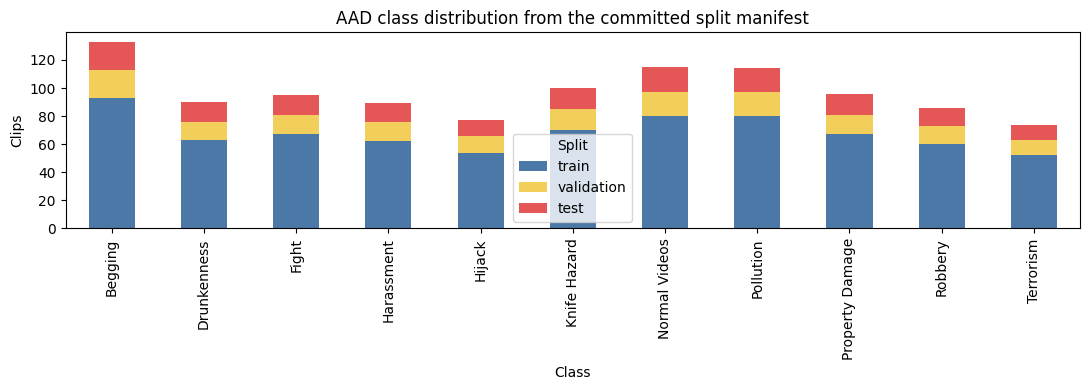

In [ ]:
first_video = preview_clips[0][1]
overview = pd.DataFrame(
    [
        ("Dataset path", str(DATASET_DIR)),
        ("Total clips", len(dataset)),
        ("Classes", dataset.num_classes),
        ("Train / validation / locked test", " / ".join(
            str(split_metadata["counts"][name])
            for name in ("train", "validation", "test")
        )),
        ("Preview tensor shape", str(tuple(first_video.shape))),
        ("Preview value range", f"{first_video.min():.3f} to {first_video.max():.3f}"),
        ("Split seed", split_metadata["seed"]),
    ],
    columns=["Item", "Value"],
)
display(overview)

class_rows = [
    {
        "Class": class_name,
        **split_metadata["class_counts"][class_name],
    }
    for class_name in dataset.class_names
]
class_counts = pd.DataFrame(class_rows)
display(class_counts)
axis = class_counts.set_index("Class")[["train", "validation", "test"]].plot(
    kind="bar",
    stacked=True,
    figsize=(11, 4),
    color=["#4c78a8", "#f2cf5b", "#e45756"],
)
axis.set_title("AAD class distribution from the committed split manifest")
axis.set_ylabel("Clips")
axis.legend(title="Split")
plt.tight_layout()
plt.show()

In [ ]:
sample_rows = []
for sample_index, video, label in preview_clips:
    source_path = dataset.samples[sample_index][0]
    sample_rows.append(
        {
            "Dataset index": sample_index,
            "Source": str(source_path.relative_to(DATASET_DIR)),
            "Class": dataset.class_names[label],
            "Tensor shape": str(tuple(video.shape)),
            "Minimum": round(float(video.min()), 3),
            "Maximum": round(float(video.max()), 3),
        }
    )
display(pd.DataFrame(sample_rows))

,Dataset index,Source,Class,Tensor shape,Minimum,Maximum
0,936,Robbery/GOPR2501_33.mp4,Robbery,"(16, 3, 32, 32)",0.000,0.731
1,166,Drunkenness/GOPR2517_39.mp4,Drunkenness,"(16, 3, 32, 32)",0.000,0.692
2,33,Begging/GP012506_126.mp4,Begging,"(16, 3, 32, 32)",0.063,1.000


## 5. Compare the native video with the model-ready clip

The first row keeps the original source playback and places the sampled,
resized model input beside it. The processed playback rate is derived from
the source duration so both players cover the same time. The online-augmented
model input remains visible underneath.

In [ ]:
def read_video_metadata(path: Path) -> tuple[float, float, int, int]:
    with av.open(str(path)) as container:
        stream = container.streams.video[0]
        native_fps = float(stream.average_rate)
        if stream.duration is not None and stream.time_base is not None:
            duration_seconds = float(stream.duration * stream.time_base)
        elif container.duration is not None:
            duration_seconds = float(container.duration / av.time_base)
        elif stream.frames:
            duration_seconds = stream.frames / native_fps
        else:
            raise ValueError(f"Could not determine video duration: {path}")
        return native_fps, duration_seconds, stream.width, stream.height

def write_preview_video(
    frames: torch.Tensor, path: Path, fps: Fraction
) -> None:
    if fps.denominator == 1:
        try:
            write_video_torchvision(frames, path, fps=int(fps))
            return
        except AttributeError as error:
            if "write_video" not in str(error):
                raise

    clip = (
        frames.detach().clamp(0.0, 1.0).mul(255).round().to(torch.uint8)
        .permute(0, 2, 3, 1).cpu().numpy()
    )
    with av.open(str(path), mode="w") as container:
        stream = container.add_stream("libx264", rate=fps)
        stream.width = int(clip.shape[2])
        stream.height = int(clip.shape[1])
        stream.pix_fmt = "yuv420p"
        for image in clip:
            frame = av.VideoFrame.from_ndarray(image, format="rgb24")
            for packet in stream.encode(frame):
                container.mux(packet)
        for packet in stream.encode():
            container.mux(packet)

sample_index, clean_video, sample_label = preview_clips[0]
with torch.random.fork_rng(devices=[]):
    torch.manual_seed(0)
    augmented_video = VideoAugmentation()(clean_video.clone())

source_path = dataset.samples[sample_index][0]
source_name = source_path.name
class_name = dataset.class_names[sample_label]
native_fps, source_duration, source_width, source_height = read_video_metadata(
    source_path
)
processed_fps = Fraction(len(clean_video) / source_duration).limit_denominator(1000)

with TemporaryDirectory() as temporary_directory:
    clean_path = Path(temporary_directory) / "model_ready.mp4"
    augmented_path = Path(temporary_directory) / "model_ready_augmented.mp4"
    write_preview_video(clean_video, clean_path, fps=processed_fps)
    write_preview_video(augmented_video, augmented_path, fps=processed_fps)
    original_player = Video(str(source_path), embed=True, width=420)._repr_html_()
    clean_player = Video(str(clean_path), embed=True, width=420)._repr_html_()
    augmented_player = Video(
        str(augmented_path), embed=True, width=420
    )._repr_html_()
    display(HTML(f"""
        <div style="display:flex; gap:2px; align-items:flex-start; flex-wrap:wrap;">
          <div style="flex:1; min-width:320px;">
            <h4>Native source: {source_name} — {class_name}</h4>
            <p>{source_width}×{source_height}, {native_fps:.2f} FPS,
               {source_duration:.2f} seconds</p>
            {original_player}
          </div>
          <div style="flex:1; min-width:320px;">
            <h4>Model-ready clip</h4>
            <p>{len(clean_video)} sampled frames at {clean_video.shape[-1]}×
               {clean_video.shape[-2]}, {float(processed_fps):.2f} FPS for
               duration-matched playback</p>
            {clean_player}
          </div>
        </div>
        <div style="margin-top:20px; max-width:440px;">
          <h4>Online-augmented model input</h4>
          <p>The same sampled frames and playback rate, with one consistent
             augmentation applied across the clip.</p>
          {augmented_player}
        </div>
    """))

mean_change = (augmented_video - clean_video).abs().mean().item()
print(f"Mean absolute augmentation change: {mean_change:.4f}")

Mean absolute augmentation change: 0.1244


## 6. Inspect the comparison roles and custom candidates

Definitions and roles come directly from the validated manifests and model
registry. Counts are computed one model at a time on the CPU, so all models
are never held in memory together.

In [ ]:
import gc
import json

from src.experiment_config import CandidateManifest
from src.experiments import model_registry
from src.model import CustomConvLSTM, PaperConvLSTM, count_trainable_parameters

CANDIDATE_MANIFEST = IMPLEMENTATION_DIR / "configs/aad_architecture_candidates.json"
CONTROLLED_PLAN = IMPLEMENTATION_DIR / "configs/aad_controlled_experiment_plan.json"
PAPER_CONFIG = IMPLEMENTATION_DIR / "configs/aad_paper_topology_reference.json"
candidate_manifest = CandidateManifest.from_json(CANDIDATE_MANIFEST)
controlled_plan = json.loads(CONTROLLED_PLAN.read_text(encoding="utf-8"))
paper_config = json.loads(PAPER_CONFIG.read_text(encoding="utf-8"))
candidate_entries = model_registry(candidate_manifest=candidate_manifest)

candidate_rows = []
for candidate, entry in zip(candidate_manifest.candidates, candidate_entries):
    candidate_model = CustomConvLSTM(
        num_classes=dataset.num_classes,
        layers=list(candidate.convlstm_layers),
        hidden_classifier_width=candidate.hidden_classifier_width,
    )
    candidate_rows.append(
        {
            "Candidate": entry["name"],
            "Ordered filters": " → ".join(
                str(filters) for filters, _ in candidate.convlstm_layers
            ),
            "Depth": len(candidate.convlstm_layers),
            "Trainable parameters": count_trainable_parameters(candidate_model),
            "Research question": entry["research_question"],
        }
    )
    del candidate_model
gc.collect()
display(pd.DataFrame(candidate_rows))

,Candidate,Ordered filters,Depth,Trainable parameters,Research question
0,custom_reference_8,8,1,3299,How does one 8-filter ConvLSTM layer perform a...
1,custom_two_layer_8_16,8 → 16,2,17275,Does increasing capacity in the second layer i...
2,custom_two_layer_16_8,16 → 8,2,18051,Does concentrating capacity in the first layer...
3,custom_two_layer_32_8,32 → 8,2,52099,Does a 32-filter first layer improve the desce...
4,custom_two_layer_64_8,64 → 8,2,175491,Does a 64-filter first layer provide useful ex...
5,custom_depth_8_8_8,8 → 8 → 8,3,12579,Does adding depth at a fixed 8-filter width im...
6,custom_capacity_early,16 → 8 → 8,3,22691,Does placing extra capacity at the start of a ...
7,custom_capacity_middle,8 → 16 → 8,3,24131,Does placing extra capacity in the middle of a...
8,custom_capacity_late,8 → 8 → 16,3,21915,Does placing extra capacity at the end of a th...
9,custom_funnel_64_16_8,64 → 16 → 8,3,207811,Does a moderate descending 64-16-8 funnel bala...


In [ ]:
standard_entries = model_registry()
paper_entry = next(
    entry for entry in standard_entries if entry["name"] == "paper_convlstm_published"
)
assert paper_entry["model_class"] == PaperConvLSTM.__name__
paper_rows = [
    {
        "Topology": paper_entry["name"],
        "Implementation": paper_entry["model_class"],
        "Role": paper_entry["role"],
        "Native protocol": "{} frames at {}×{}".format(
            paper_config["sequence_length"], paper_config["height"], paper_config["width"]
        ),
        "Notebook action": "Audited listing only; no forward allocation",
    }
]
baseline_rows = [
    {
        "Baseline": entry["name"],
        "Implementation": entry["model_class"],
        "Role": entry["role"],
    }
    for entry in standard_entries
    if entry["family"] == "3D-CNN"
]
display(HTML("<h4>Published ConvLSTM topology (separate protocol)</h4>"))
display(pd.DataFrame(paper_rows))
display(HTML("<h4>Practical 3D-CNN baselines for this study</h4>"))
display(pd.DataFrame(baseline_rows))

,Topology,Implementation,Role,Native protocol,Notebook action
0,paper_convlstm_published,PaperConvLSTM,source-paper ConvLSTM topology baseline,50 frames at 50×50,Audited listing only; no forward allocation


,Baseline,Implementation,Role
0,r3d_18,torchvision.models.video.r3d_18,study practical baseline trained from scratch
1,mc3_18,torchvision.models.video.mc3_18,study practical baseline trained from scratch
2,r2plus1d_18,torchvision.models.video.r2plus1d_18,study practical baseline trained from scratch


## 7. Inspect the planned lightweight reference

The controlled plan currently names this model as a reference for later
comparisons. It is a placeholder, not a selected winner or final model.

In [ ]:
planned_reference_name = controlled_plan["reference_candidate"]
planned_candidate = next(
    candidate
    for candidate in candidate_manifest.candidates
    if candidate.name == planned_reference_name
)
seed_everything(SEED)
device = torch.device("cuda")
smoke_model = CustomConvLSTM(
    num_classes=dataset.num_classes,
    layers=list(planned_candidate.convlstm_layers),
    hidden_classifier_width=planned_candidate.hidden_classifier_width,
).to(device).eval()
model_configuration = smoke_model.configuration()

layer_rows = []
input_channels = model_configuration["input_channels"]
for layer_number, layer in enumerate(model_configuration["layers"], start=1):
    layer_rows.append(
        {
            "Layer": f"ConvLSTM {layer_number}",
            "Input channels": input_channels,
            "Output filters": layer["filters"],
            "Kernel": "×".join(str(value) for value in layer["kernel_size"]),
            "Temporal output": (
                "full sequence"
                if layer_number < len(model_configuration["layers"])
                else "final frame state"
            ),
        }
    )
    input_channels = layer["filters"]
display(pd.DataFrame(layer_rows))

trainable_parameters = count_trainable_parameters(smoke_model)
parameter_memory_mib = sum(
    parameter.numel() * parameter.element_size()
    for parameter in smoke_model.parameters()
) / (1024 ** 2)
display(pd.DataFrame(
    [
        ("Plan reference", planned_reference_name),
        ("Status", "Planned reference only; not selected or final"),
        ("Input shape", str((1, *clean_video.shape))),
        ("Expected logits shape", str((1, dataset.num_classes))),
        ("Trainable parameters", f"{trainable_parameters:,}"),
        ("Parameter allocation", f"{parameter_memory_mib:.2f} MiB on {device}"),
    ],
    columns=["Item", "Value"],
))

,Layer,Input channels,Output filters,Kernel,Temporal output
0,ConvLSTM 1,3,8,3×3,full sequence
1,ConvLSTM 2,8,8,3×3,full sequence
2,ConvLSTM 3,8,8,3×3,final frame state


,Item,Value
0,Plan reference,custom_depth_8_8_8
1,Status,Planned reference only; not selected or final
2,Input shape,"(1, 16, 3, 32, 32)"
3,Expected logits shape,"(1, 11)"
4,Trainable parameters,"12,579"
5,Parameter allocation,0.05 MiB on cuda


## 8. Confirm untrained inference plumbing

Three reproducible training clips now pass through the planned custom model.
The model has random weights: these checks confirm tensor shapes, executable
inference, class mapping, and video presentation—not model performance.

### 8.1 Check input and output shapes

Inference runs one clip at a time on the A100. Only probabilities and labels
return to the CPU; no test clip or checkpoint is opened.

In [ ]:
torch.cuda.reset_peak_memory_stats(device)
prediction_checks = []
with torch.inference_mode():
    for sample_index, video, true_label in preview_clips:
        inference_input = video.unsqueeze(0).to(device)
        logits = smoke_model(inference_input)
        probabilities = torch.softmax(logits, dim=1)[0]
        top_probabilities, top_indices = torch.topk(
            probabilities, k=min(3, dataset.num_classes)
        )
        source_path = dataset.samples[sample_index][0]
        prediction_checks.append({
            "Dataset index": sample_index,
            "Source": source_path.name,
            "True class": dataset.class_names[true_label],
            "Predicted class": dataset.class_names[int(top_indices[0])],
            "Top probability": float(top_probabilities[0]),
            "Input shape": tuple(inference_input.shape),
            "Output shape": tuple(logits.shape),
            "Top three": [
                (dataset.class_names[int(class_index)], float(probability))
                for probability, class_index in zip(
                    top_probabilities.cpu(), top_indices.cpu()
                )
            ],
        })
        del inference_input, logits, probabilities
        del top_probabilities, top_indices

shape_rows = [{
    "Source": check["Source"],
    "Input tensor": str(check["Input shape"]),
    "Output logits": str(check["Output shape"]),
} for check in prediction_checks]
display(pd.DataFrame(shape_rows))
print("Model:", planned_reference_name)
print("Weights: random / untrained")
print(f"Peak CUDA allocation: {torch.cuda.max_memory_allocated(device) / (1024 ** 2):.2f} MiB")

,Source,Input tensor,Output logits
0,GOPR2501_33.mp4,"(1, 16, 3, 32, 32)","(1, 11)"
1,GOPR2517_39.mp4,"(1, 16, 3, 32, 32)","(1, 11)"
2,GP012506_126.mp4,"(1, 16, 3, 32, 32)","(1, 11)"


Model: custom_depth_8_8_8
Weights: random / untrained
Peak CUDA allocation: 19.97 MiB


### 8.2 Watch clips with their random-weight predictions

Each card uses the model-ready tensor and duration-matched playback. The true
label verifies mapping only; it is not used for selection.

In [ ]:
display(pd.DataFrame([{
    "Source": check["Source"],
    "True class": check["True class"],
    "Random prediction": check["Predicted class"],
    "Random confidence": check["Top probability"],
} for check in prediction_checks]))

for check, (_, video, _) in zip(prediction_checks, preview_clips):
    source_path = dataset.samples[check["Dataset index"]][0]
    _, source_duration, _, _ = read_video_metadata(source_path)
    playback_rate = Fraction(len(video) / source_duration).limit_denominator(1000)
    with TemporaryDirectory() as temporary_directory:
        prediction_path = Path(temporary_directory) / "prediction.mp4"
        write_preview_video(video, prediction_path, fps=playback_rate)
        player = Video(str(prediction_path), embed=True, width=420)._repr_html_()
        source = check["Source"]
        true_name = check["True class"]
        predicted_name = check["Predicted class"]
        confidence = check["Top probability"]
        top_three = ", ".join(
            f"{name}: {probability:.3f}"
            for name, probability in check["Top three"]
        )
        display(HTML(f"""
          <div style="border:1px solid #bbb; border-radius:8px; padding:12px;
                      margin:12px 0; max-width:460px;">
            <h4>{source}</h4>
            <p><b>True class:</b> {true_name}<br>
               <b>Random prediction:</b> {predicted_name} ({confidence:.3f})<br>
               <b>Top three:</b> {top_three}</p>
            {player}
          </div>
        """))

,Source,True class,Random prediction,Random confidence
0,GOPR2501_33.mp4,Robbery,Robbery,0.117455
1,GOPR2517_39.mp4,Drunkenness,Robbery,0.117486
2,GP012506_126.mp4,Begging,Robbery,0.117534


### 8.3 What this check proves

- The custom architecture accepts real (1, 16, 3, 32, 32) input.
- It returns one logit per AAD class and maps indices to class names.
- Each displayed video is the same tensor supplied to the model.
- Random confidence and apparent correctness are not accuracy evidence.
- Loss curves become meaningful only after training.

In [ ]:
del smoke_model
gc.collect()
torch.cuda.empty_cache()
print(f"CUDA allocated after cleanup: {torch.cuda.memory_allocated(device) / (1024 ** 2):.2f} MiB")

CUDA allocated after cleanup: 18.20 MiB


## 9. Run an optional 512-step learning sanity check

This bounded run checks the complete training, validation, saving, plotting, and prediction pipeline before the controlled experiments. It is **not** model-selection evidence. It uses training and validation clips only; the test split remains locked.

### 9.1 Configure the bounded run

Leave the flag false when inspecting the notebook. Set it to true only when you are ready to spend roughly 512 optimizer updates (about 11 epochs) on the connected A100.

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from src.dataset import AugmentSubset
from src.metrics import evaluate_classifier, train_classifier_steps
from src.utils import (
    RunContext,
    data_loader_generator,
    seed_data_loader_worker,
    write_json,
)

RUN_SMOKE_TRAINING = True
SMOKE_TRAINING_STEPS = 512
SMOKE_VALIDATION_INTERVAL = 64
SMOKE_BATCH_SIZE = 16
SMOKE_LEARNING_RATE = 0.001
SMOKE_WEIGHT_DECAY = 0.001

if SMOKE_TRAINING_STEPS <= 0:
    raise ValueError("SMOKE_TRAINING_STEPS must be positive")
if SMOKE_VALIDATION_INTERVAL <= 0:
    raise ValueError("SMOKE_VALIDATION_INTERVAL must be positive")
if SMOKE_TRAINING_STEPS % SMOKE_VALIDATION_INTERVAL != 0:
    raise ValueError("Training steps must divide into validation intervals")

print("Planned model:", planned_reference_name)
print("Optimizer updates:", SMOKE_TRAINING_STEPS)
validation_steps = list(range(
    SMOKE_VALIDATION_INTERVAL,
    SMOKE_TRAINING_STEPS + 1,
    SMOKE_VALIDATION_INTERVAL,
))
print("Validation steps:", validation_steps)
print("Test access: locked")
print("Run enabled:", RUN_SMOKE_TRAINING)

Planned model: custom_depth_8_8_8
Optimizer updates: 512
Validation steps: [64, 128, 192, 256, 320, 384, 448, 512]
Test access: locked
Run enabled: True


### 9.2 Train and save the learning sanity model

Set RUN_SMOKE_TRAINING = True in the cell above, rerun it, then run this cell. Progress is reported after each 64-step block. The checkpoint is the last sanity-check step, not a validation-selected final model.

In [ ]:
smoke_training_model = None
smoke_training_run = None
smoke_training_history = []
smoke_validation_history = []
smoke_checkpoint_path = None
smoke_configuration_path = None
smoke_history_path = None
smoke_loss_curve_path = None

if not RUN_SMOKE_TRAINING:
    print("Learning sanity training disabled. Set RUN_SMOKE_TRAINING = True to run it.")
else:
    deterministic_settings = seed_everything(SEED)
    augmented_training = AugmentSubset(train_subset, VideoAugmentation())
    training_loader = DataLoader(
        augmented_training,
        batch_size=SMOKE_BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        worker_init_fn=seed_data_loader_worker,
        generator=data_loader_generator(SEED),
    )
    validation_loader = DataLoader(
        validation_subset,
        batch_size=SMOKE_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        worker_init_fn=seed_data_loader_worker,
        generator=data_loader_generator(SEED + 1),
    )
    smoke_training_model = CustomConvLSTM(
        num_classes=dataset.num_classes,
        layers=list(planned_candidate.convlstm_layers),
        hidden_classifier_width=planned_candidate.hidden_classifier_width,
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        smoke_training_model.parameters(),
        lr=SMOKE_LEARNING_RATE,
        weight_decay=SMOKE_WEIGHT_DECAY,
    )
    smoke_arguments = {
        "model": planned_reference_name,
        "steps": SMOKE_TRAINING_STEPS,
        "validation_interval": SMOKE_VALIDATION_INTERVAL,
        "batch_size": SMOKE_BATCH_SIZE,
        "learning_rate": SMOKE_LEARNING_RATE,
        "weight_decay": SMOKE_WEIGHT_DECAY,
        "sequence_length": SEQUENCE_LENGTH,
        "frame_size": list(FRAME_SIZE),
        "seed": SEED,
        "augmentation": True,
        "test_access": "locked",
    }
    smoke_training_run = RunContext(
        IMPLEMENTATION_DIR / "runs",
        purpose="train",
        dataset_path=DATASET_DIR,
        label="learning-sanity-512-steps",
        arguments=smoke_arguments,
        metadata={
            "evidence_role": "pipeline_learning_sanity_only",
            "selection_partition": None,
            "validation_partition": "validation",
            "test_access": "locked",
        },
    )
    smoke_training_run.update({
        "class_names": dataset.class_names,
        "model_configuration": smoke_training_model.configuration(),
        "trainable_parameters": count_trainable_parameters(smoke_training_model),
        "split": split_metadata,
        "deterministic_settings": deterministic_settings,
    })
    completed_steps = 0
    while completed_steps < SMOKE_TRAINING_STEPS:
        step_records = train_classifier_steps(
            smoke_training_model,
            training_loader,
            criterion,
            optimizer,
            device,
            max_steps=SMOKE_VALIDATION_INTERVAL,
        )
        for record in step_records:
            record["step"] = int(record["step"]) + completed_steps
        smoke_training_history.extend(step_records)
        completed_steps += SMOKE_VALIDATION_INTERVAL
        validation_metrics = evaluate_classifier(
            smoke_training_model,
            validation_loader,
            criterion,
            device,
            dataset.num_classes,
        )
        smoke_validation_history.append({
            "step": completed_steps,
            **validation_metrics,
        })
        recent_loss = sum(
            float(record["loss"]) for record in step_records
        ) / len(step_records)
        validation_loss = validation_metrics["loss"]
        print(
            f"Step {completed_steps:>2}/{SMOKE_TRAINING_STEPS} | "
            f"recent train loss {recent_loss:.4f} | "
            f"validation loss {validation_loss:.4f}"
        )

    smoke_configuration_path = write_json(
        smoke_training_run.run_dir / "configuration.json",
        {
            "arguments": smoke_arguments,
            "model": smoke_training_model.configuration(),
            "class_names": dataset.class_names,
            "split": split_metadata,
            "deterministic_settings": deterministic_settings,
            "evidence_role": "pipeline_learning_sanity_only",
        },
    )
    smoke_history_path = write_json(
        smoke_training_run.run_dir / "metrics" / "history.json",
        {
            "training_steps": smoke_training_history,
            "validation": smoke_validation_history,
            "validation_interval": SMOKE_VALIDATION_INTERVAL,
            "test_access": "locked",
            "evidence_role": "pipeline_learning_sanity_only",
        },
    )
    smoke_checkpoint_path = (
        smoke_training_run.run_dir / "checkpoints" / "sanity_model.pth"
    )
    smoke_checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "checkpoint_role": "pipeline_learning_sanity_last_step",
            "evidence_role": "pipeline_learning_sanity_only",
            "completed_steps": SMOKE_TRAINING_STEPS,
            "model_state_dict": smoke_training_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "model_config": smoke_training_model.configuration(),
            "training_config": smoke_arguments,
            "validation_metrics": smoke_validation_history[-1],
            "class_names": dataset.class_names,
            "split_manifest_hash": split_metadata["manifest_hash"],
            "seed": SEED,
            "selection_partition": None,
            "test_access": "locked",
        },
        smoke_checkpoint_path,
    )
    print("Saved learning-sanity checkpoint:", smoke_checkpoint_path)
    print("Saved metric history:", smoke_history_path)

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step 64/512 | recent train loss 2.4175 | validation loss 2.3981
Step 128/512 | recent train loss 2.4113 | validation loss 2.3925


### 9.3 Inspect and save the loss curves

The noisy per-step training loss and eight full-validation measurements are shown together. This longer check should reveal clear learning, but it is still not architecture-selection evidence.

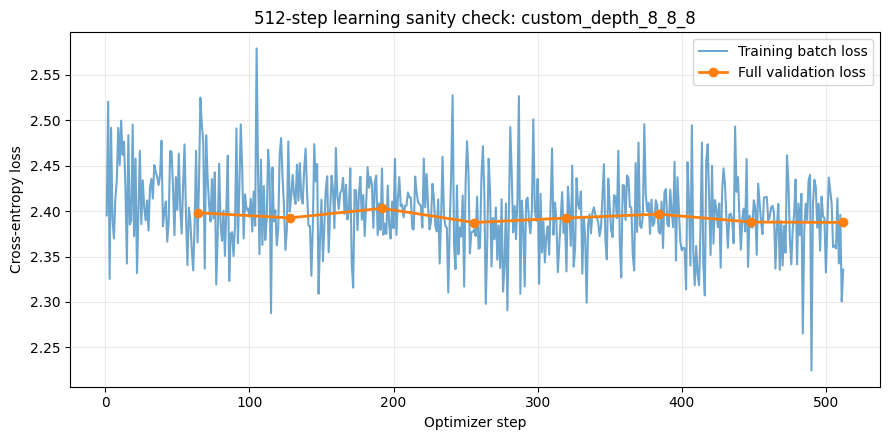

,step,loss,accuracy,macro_precision,macro_recall,macro_f1
0,64,2.398074,0.08125,0.007386,0.090909,0.013663
1,128,2.392458,0.11875,0.011216,0.086364,0.019854
2,192,2.402980,0.07500,0.007322,0.064171,0.013143
3,256,2.387369,0.11875,0.010863,0.086364,0.019299
4,320,2.392294,0.10625,0.009659,0.090909,0.017463
5,384,2.396572,0.10625,0.009659,0.090909,0.017463
6,448,2.387859,0.15000,0.086974,0.113102,0.059379
7,512,2.387430,0.15000,0.061944,0.113102,0.055167


Saved loss curves: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_095917_629839_abnormal-activities-dataset_learning-sanity-512-steps/plots/loss_curves.png


In [ ]:
if not smoke_training_history:
    print("No learning-sanity history yet. Enable and run the training cell first.")
else:
    training_frame = pd.DataFrame(smoke_training_history)
    validation_frame = pd.DataFrame(smoke_validation_history)
    figure, axis = plt.subplots(figsize=(9, 4.5))
    axis.plot(
        training_frame["step"],
        training_frame["loss"],
        alpha=0.65,
        label="Training batch loss",
    )
    axis.plot(
        validation_frame["step"],
        validation_frame["loss"],
        marker="o",
        linewidth=2,
        label="Full validation loss",
    )
    axis.set(
        title=f"512-step learning sanity check: {planned_reference_name}",
        xlabel="Optimizer step",
        ylabel="Cross-entropy loss",
    )
    axis.grid(alpha=0.25)
    axis.legend()
    figure.tight_layout()
    smoke_loss_curve_path = (
        smoke_training_run.run_dir / "plots" / "loss_curves.png"
    )
    smoke_loss_curve_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(smoke_loss_curve_path, dpi=180, bbox_inches="tight")
    plt.show()
    display(validation_frame[[
        "step", "loss", "accuracy", "macro_precision",
        "macro_recall", "macro_f1",
    ]])
    print("Saved loss curves:", smoke_loss_curve_path)

### 9.4 Review three validation predictions

These reproducible clean validation clips verify post-training inference and display whether each prediction matches its label. They do not prove model quality, and the locked test split is not read.

In [ ]:
if smoke_training_model is None:
    print("No learning-sanity model yet. Enable and run the training cell first.")
else:
    validation_indices = random.Random(SEED).sample(
        list(validation_subset.indices),
        min(3, len(validation_subset)),
    )
    smoke_training_model.eval()
    validation_prediction_records = []
    validation_prediction_clips = []
    with torch.inference_mode():
        for sample_index in validation_indices:
            video, true_label = dataset[sample_index]
            logits = smoke_training_model(video.unsqueeze(0).to(device))
            probabilities = torch.softmax(logits, dim=1)[0]
            confidence, predicted_label = probabilities.max(dim=0)
            predicted_label = int(predicted_label)
            source_path = dataset.samples[sample_index][0]
            record = {
                "dataset_index": sample_index,
                "source": str(source_path.relative_to(DATASET_DIR)),
                "true_class": dataset.class_names[true_label],
                "predicted_class": dataset.class_names[predicted_label],
                "confidence": float(confidence),
                "correct": predicted_label == true_label,
                "partition": "validation",
            }
            validation_prediction_records.append(record)
            validation_prediction_clips.append((source_path, video, record))

    display(pd.DataFrame([{
        "Source": record["source"],
        "True class": record["true_class"],
        "Prediction": record["predicted_class"],
        "Confidence": round(record["confidence"], 4),
        "Correct": record["correct"],
    } for record in validation_prediction_records]))

    for source_path, video, record in validation_prediction_clips:
        _, source_duration, _, _ = read_video_metadata(source_path)
        playback_rate = Fraction(
            len(video) / source_duration
        ).limit_denominator(1000)
        with TemporaryDirectory() as temporary_directory:
            prediction_path = Path(temporary_directory) / "prediction.mp4"
            write_preview_video(video, prediction_path, fps=playback_rate)
            player = Video(
                str(prediction_path), embed=True, width=420
            )._repr_html_()
            border_colour = "#2e7d32" if record["correct"] else "#c62828"
            result_label = "correct" if record["correct"] else "incorrect"
            source = record["source"]
            true_class = record["true_class"]
            predicted_class = record["predicted_class"]
            confidence = record["confidence"]
            display(HTML(f"""
              <div style="border:2px solid {border_colour}; border-radius:8px;
                          padding:12px; margin:12px 0; max-width:460px;">
                <h4>{source}</h4>
                <p><b>True:</b> {true_class}<br>
                   <b>Predicted:</b> {predicted_class} ({confidence:.3f})<br>
                   <b>Result:</b> {result_label}</p>
                {player}
              </div>
            """))

    smoke_predictions_path = write_json(
        smoke_training_run.run_dir / "predictions" / "validation.json",
        {
            "partition": "validation",
            "test_access": "locked",
            "evidence_role": "pipeline_learning_sanity_only",
            "predictions": validation_prediction_records,
        },
    )
    smoke_artifacts = {
        "configuration": str(smoke_configuration_path),
        "history": str(smoke_history_path),
        "checkpoint": str(smoke_checkpoint_path),
        "validation_predictions": str(smoke_predictions_path),
    }
    if smoke_loss_curve_path is not None:
        smoke_artifacts["loss_curves"] = str(smoke_loss_curve_path)
    smoke_training_run.complete(
        artifacts=smoke_artifacts,
        results={
            "completed_steps": SMOKE_TRAINING_STEPS,
            "final_validation": smoke_validation_history[-1],
            "test_access": "locked",
            "evidence_role": "pipeline_learning_sanity_only",
        },
    )
    print("Completed learning sanity run:", smoke_training_run.run_dir)
    del training_loader, validation_loader, smoke_training_model
    smoke_training_model = None
    gc.collect()
    torch.cuda.empty_cache()

,Source,True class,Prediction,Confidence,Correct
0,Drunkenness/GOPR2517_65.mp4,Drunkenness,Begging,0.1092,False
1,Begging/GP012506_46.mp4,Begging,Begging,0.1082,True
2,Hijack/GP012527_40.mp4,Hijack,Begging,0.1093,False


Completed learning sanity run: /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs/train/20261004_095917_629839_abnormal-activities-dataset_learning-sanity-512-steps


### 9.5 What this sanity check proves

A completed run proves that optimization, validation, checkpoint saving, curves, and visual inference work together. Its saved checkpoint is useful for debugging, but 512 steps do **not** establish the best architecture or a paper result.

## 9.6 Run the bounded VDD learnability diagnostic

This diagnostic first inventories VDD and tries to overfit a fixed balanced training subset. Only after reaching 95% training accuracy with decreasing loss does it run one bounded train/validation check. It records validation separately, never decodes the test partition for training or evaluation, and labels every artifact `pipeline_learnability_diagnostic`.

In [ ]:
RUN_VDD_DIAGNOSTIC = True
# Keep one assignment active. accepted_classes=None uses every VDD class.
DIAGNOSTIC_DATASET = {
    "name": "vdd",
    "kaggle_handle": "sanelehlabisa/violence-detection-dataset",
    "accepted_classes": None,
}
# Before enabling Kinetics, replace the example names with exact directory names
# approved by ticket 036. A missing name stops the run; it never loads all classes.
# DIAGNOSTIC_DATASET = {
#     "name": "kinetics-subset",
#     "kaggle_handle": "sanelehlabisa/kinetics-400-dataset",
#     "accepted_classes": ["approved-class-1", "approved-class-2"],
# }
VDD_TINY_EPOCHS = 30
VDD_BOUNDED_EPOCHS = 12

print("Evidence role: pipeline_learnability_diagnostic")
print("Selected dataset:", DIAGNOSTIC_DATASET["name"])
print("Accepted classes:", DIAGNOSTIC_DATASET["accepted_classes"] or "all dataset classes")
print("Run enabled:", RUN_VDD_DIAGNOSTIC)
print("Test access: locked")

In [ ]:
if not RUN_VDD_DIAGNOSTIC:
    print("VDD diagnostic disabled.")
else:
    import kagglehub
    import shlex

    diagnostic_download_root = Path(
        kagglehub.dataset_download(DIAGNOSTIC_DATASET["kaggle_handle"])
    )
    vdd_command = [
        sys.executable,
        "-m",
        "src.vdd_diagnostic",
        "--dataset-dir",
        str(diagnostic_download_root),
        "--runs-dir",
        str(IMPLEMENTATION_DIR / "runs"),
        "--manifest",
        str(IMPLEMENTATION_DIR / "runs" / f"{DIAGNOSTIC_DATASET['name']}_diagnostic_seed42.json"),
        "--tiny-epochs",
        str(VDD_TINY_EPOCHS),
        "--bounded-epochs",
        str(VDD_BOUNDED_EPOCHS),
    ]
    for accepted_class in DIAGNOSTIC_DATASET["accepted_classes"] or []:
        vdd_command.extend(["--accepted-class", accepted_class])
    print("Running:", shlex.join(vdd_command))
    subprocess.run(vdd_command, cwd=IMPLEMENTATION_DIR, check=True)

## 10. Inspect and run one controlled experiment stage

This section delegates all training, checkpoint selection, metrics, and artifacts to src.experiments. It runs only one explicitly selected stage and never opens the test split.

### 10.1 Review the complete plan

This table is safe to run: it validates configuration files without loading AAD or allocating a model.

In [ ]:
import shlex

from src.experiments import (
    build_plan_commands,
    controlled_plan_rows,
    inspect_experiment_run_directories,
)

plan_rows = controlled_plan_rows(CONTROLLED_PLAN)
plan_frame = pd.DataFrame(plan_rows).rename(columns={
    "stage": "Stage",
    "trial": "Trial",
    "model_role": "Models / role",
    "changed_factor": "Changed factor",
    "seeds": "Seeds",
    "input_size": "Input",
    "epochs": "Epochs",
    "augmentation": "Augmentation",
    "weight_decay": "Weight decay",
    "expected_runs": "Expected runs",
})
display(plan_frame)
print("Expected leaf runs across all stages:", int(plan_frame["Expected runs"].sum()))
print("Selection partition: validation only | Test access: locked")

,Stage,Trial,Models / role,Changed factor,Seeds,Input,Epochs,Augmentation,Weight decay,Expected runs
0,architecture-screen,all_custom_candidates,11 custom candidates,architecture width/depth,42,"T=16, 32x32",24,True,0.0010,1
1,baseline-confirmation,reference_and_practical_baselines,custom_depth_8_8_8 + r3d_18 + mc3_18 + r2plus1...,model family,"42, 2026","T=16, 32x32",64,True,0.0010,2
2,published-topology,source_paper_topology,PaperConvLSTM (separate protocol),published topology,42,"T=50, 50x50",64,True,0.0010,1
3,focused-ablations,reference,custom_depth_8_8_8,reference,"42, 2026","T=16, 32x32",64,True,0.0010,2
4,focused-ablations,weight_decay_0,custom_depth_8_8_8,weight_decay,"42, 2026","T=16, 32x32",64,True,0.0000,2
5,focused-ablations,weight_decay_0_0001,custom_depth_8_8_8,weight_decay,"42, 2026","T=16, 32x32",64,True,0.0001,2
6,focused-ablations,augmentation_off,custom_depth_8_8_8,augmentation,"42, 2026","T=16, 32x32",64,False,0.0010,2
7,focused-ablations,spatial_64,custom_depth_8_8_8,spatial_size,"42, 2026","T=16, 64x64",64,True,0.0010,2
8,focused-ablations,sequence_32,custom_depth_8_8_8,sequence_length,"42, 2026","T=32, 32x32",64,True,0.0010,2


Expected leaf runs across all stages: 16
Selection partition: validation only | Test access: locked


### 10.2 Select one stage and preview its exact commands

For the first full screen, record the ticket-021 choice as skip or expanded before enabling execution. Leave the run flag false while reviewing commands.

In [ ]:
VALID_EXPERIMENT_STAGES = {
    "architecture-screen",
    "baseline-confirmation",
    "published-topology",
    "focused-ablations",
}
SELECTED_EXPERIMENT_STAGE = "architecture-screen"
CANDIDATE_EXPANSION_DECISION = "pending"  # pending, skip, or expanded
REFERENCE_CANDIDATE = None
RUN_EXPERIMENTS = True
EXISTING_STAGE_RUNS = []
MAX_VISUAL_MODELS = 3

if SELECTED_EXPERIMENT_STAGE not in VALID_EXPERIMENT_STAGES:
    raise ValueError(f"Unknown experiment stage: {SELECTED_EXPERIMENT_STAGE}")
if CANDIDATE_EXPANSION_DECISION not in {"pending", "skip", "expanded"}:
    raise ValueError("Candidate decision must be pending, skip, or expanded")
if not CONTROLLED_PLAN.is_file():
    raise FileNotFoundError(f"Controlled plan not found: {CONTROLLED_PLAN}")

EXPERIMENT_RUNS_ROOT = IMPLEMENTATION_DIR / "runs"
stage_command = [
    sys.executable,
    "-m",
    "src.experiments",
    "--plan-config",
    str(CONTROLLED_PLAN),
    "--run-plan-stage",
    SELECTED_EXPERIMENT_STAGE,
    "--plan-dataset-dir",
    str(DATASET_DIR),
    "--plan-runs-dir",
    str(EXPERIMENT_RUNS_ROOT),
]
if REFERENCE_CANDIDATE is not None:
    stage_command.extend(["--reference-candidate", REFERENCE_CANDIDATE])

leaf_commands = build_plan_commands(
    CONTROLLED_PLAN,
    SELECTED_EXPERIMENT_STAGE,
    reference_candidate=REFERENCE_CANDIDATE,
    dataset_dir=str(DATASET_DIR),
    runs_dir=str(EXPERIMENT_RUNS_ROOT),
)
display(pd.DataFrame([
    {"Leaf run": name, "Command": shlex.join(command)}
    for name, command in leaf_commands
]))
print("Stage command:")
print(shlex.join(stage_command))
print("Candidate expansion decision:", CANDIDATE_EXPANSION_DECISION)
print("Execution enabled:", RUN_EXPERIMENTS)
stage_run_directories = [Path(path).expanduser().resolve() for path in EXISTING_STAGE_RUNS]

,Leaf run,Command
0,architecture_screen,/usr/bin/python3 -m src.experiments --config /...


Stage command:
/usr/bin/python3 -m src.experiments --plan-config /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/configs/aad_controlled_experiment_plan.json --run-plan-stage architecture-screen --plan-dataset-dir /root/.cache/kagglehub/datasets/sanelehlabisa/abnormal-activities-dataset/versions/2/abnormal-activities-dataset --plan-runs-dir /content/phd_research/papers/001-journal-abnormal-activity-recognition/implementation/runs
Candidate expansion decision: pending
Execution enabled: True


### 10.3 Run the selected stage

Set RUN_EXPERIMENTS = True only after checking the table and command. Output streams live from the existing runner. Failure stops the stage; nothing is retried or silently continued.

In [ ]:
if not RUN_EXPERIMENTS:
    print("Experiment execution disabled. Review the plan and command first.")
else:
    if (
        SELECTED_EXPERIMENT_STAGE == "architecture-screen"
        and CANDIDATE_EXPANSION_DECISION == "pending"
    ):
        raise ValueError(
            "Record ticket 021 as skip or expanded before architecture screening"
        )
    experiments_root = EXPERIMENT_RUNS_ROOT / "experiments"
    before_runs = (
        {path.resolve() for path in experiments_root.iterdir() if path.is_dir()}
        if experiments_root.is_dir()
        else set()
    )
    print("$", shlex.join(stage_command), flush=True)
    process = subprocess.Popen(
        stage_command,
        cwd=IMPLEMENTATION_DIR,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    if process.stdout is None:
        raise RuntimeError("Could not capture experiment output")
    for output_line in process.stdout:
        print(output_line, end="", flush=True)
    return_code = process.wait()
    after_runs = (
        {path.resolve() for path in experiments_root.iterdir() if path.is_dir()}
        if experiments_root.is_dir()
        else set()
    )
    stage_run_directories = sorted(after_runs - before_runs)
    print("New run directories:", len(stage_run_directories))
    for run_directory in stage_run_directories:
        print(" -", run_directory)
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, stage_command)

ValueError: Record ticket 021 as skip or expanded before architecture screening

### 10.4 Inspect validation evidence from this stage

Only explicitly recorded run directories are inspected. Partial runs are labelled but never ranked. Complete summaries show validation metrics, parameters, runtime, loss curves, and up to three confusion matrices.

In [ ]:
from IPython.display import Image

experiment_records = inspect_experiment_run_directories(stage_run_directories)
if not experiment_records:
    print("No stage runs selected. Run a stage or add exact paths to EXISTING_STAGE_RUNS.")
else:
    display(pd.DataFrame([
        {
            "Run directory": record["run_dir"],
            "Evidence state": record["evidence_state"],
            "Manifest status": (record["manifest"] or {}).get("status"),
        }
        for record in experiment_records
    ]))

    for record in experiment_records:
        run_dir = Path(record["run_dir"])
        if record["evidence_state"] != "complete":
            print(f"Skipping ranking for {run_dir.name}: {record['evidence_state']}")
            continue
        manifest = record["manifest"]
        summary = record["summary"]
        ranked = summary["ranked"]
        print(f"\nComplete validation evidence: {run_dir.name}")
        display(pd.DataFrame([
            {
                "Rank": rank,
                "Model": result["name"],
                "Role": result["role"],
                "Validation loss": result["validation_metrics"]["loss"],
                "Validation accuracy": result["validation_metrics"]["accuracy"],
                "Validation macro-F1": result["validation_metrics"]["macro_f1"],
                "Parameters": result["num_params"],
                "Train seconds": result["train_time_s"],
                "Selected epoch": result["checkpoint_selection"]["selected_epoch"],
            }
            for rank, result in enumerate(ranked, start=1)
        ]))
        display(pd.DataFrame([
            ("Status", manifest.get("status")),
            ("Git revision", manifest.get("git_revision")),
            ("Seed", manifest.get("seed")),
            ("Test access", manifest.get("test_access")),
            ("Dataset", manifest.get("dataset_path")),
        ], columns=["Provenance", "Value"]))

        for result in ranked[:MAX_VISUAL_MODELS]:
            history_path = Path(result["history"])
            if history_path.is_file():
                history = json.loads(history_path.read_text(encoding="utf-8"))
                epochs = history.get("epochs", [])
                if epochs:
                    epoch_numbers = [item["epoch"] for item in epochs]
                    training_losses = [item["training_metrics"]["loss"] for item in epochs]
                    validation_losses = [item["validation_metrics"]["loss"] for item in epochs]
                    figure, axis = plt.subplots(figsize=(8, 4))
                    axis.plot(epoch_numbers, training_losses, label="Training loss")
                    axis.plot(epoch_numbers, validation_losses, label="Validation loss")
                    axis.set(
                        title=f"{result['name']} — validation-selected training",
                        xlabel="Epoch",
                        ylabel="Cross-entropy loss",
                    )
                    axis.grid(alpha=0.25)
                    axis.legend()
                    figure.tight_layout()
                    plt.show()
            confusion = result.get("validation_confusion_matrix", {})
            confusion_path = Path(confusion.get("png", ""))
            if confusion_path.is_file():
                display(HTML(f"<h4>{result['name']} validation confusion matrix</h4>"))
                display(Image(filename=str(confusion_path), width=720))

No stage runs selected. Run a stage or add exact paths to EXISTING_STAGE_RUNS.


### 10.5 Execution order

First record the ticket-021 decision, then run architecture-screen only. Ticket 025 uses the complete validation screen to freeze the reference before baseline confirmation and ablations. Do not automatically chain stages or inspect test data.

## 11. Next: run the controlled AAD evidence plan

Use ticket 025 after the candidate-block decision. Ticket 026 trains the validation-selected configuration with the full confirmation budget, and ticket 027 performs its one-time final AAD evaluation with complete metrics and prediction examples.